
Processing: DBRA24
  Head-A Driver Anomaly -> target: anomalous_event
    ECE=0.0042, Brier=0.0908, NLL=0.3273
  Head-B Route Deviation Score -> target: route_deviation_score
    ECE=0.0001, Brier=0.1876, NLL=0.5626
  Head-C Route Anomaly -> target: route_anomaly
    ECE=0.0001, Brier=0.0912, NLL=0.3285

Processing: V2X-CDD
  Head-A Driver Anomaly -> target: collision_detected
    ECE=0.0003, Brier=0.0496, NLL=0.2061
  Head-B Route Deviation Score -> target: latency_ms
    ECE=0.0007, Brier=0.1882, NLL=0.5641
  Head-C Route Anomaly -> target: collision_detected
    ECE=0.0003, Brier=0.0496, NLL=0.2061

Processing: VT-DBA
  Head-A Driver Anomaly -> target: behavior_label
    ECE=0.0005, Brier=0.0000, NLL=0.0005
  Head-B Route Deviation Score -> target: lane_deviation
    ECE=0.0171, Brier=0.0927, NLL=0.2924
  Head-C Route Anomaly -> target: behavior_label
    ECE=0.0005, Brier=0.0000, NLL=0.0005


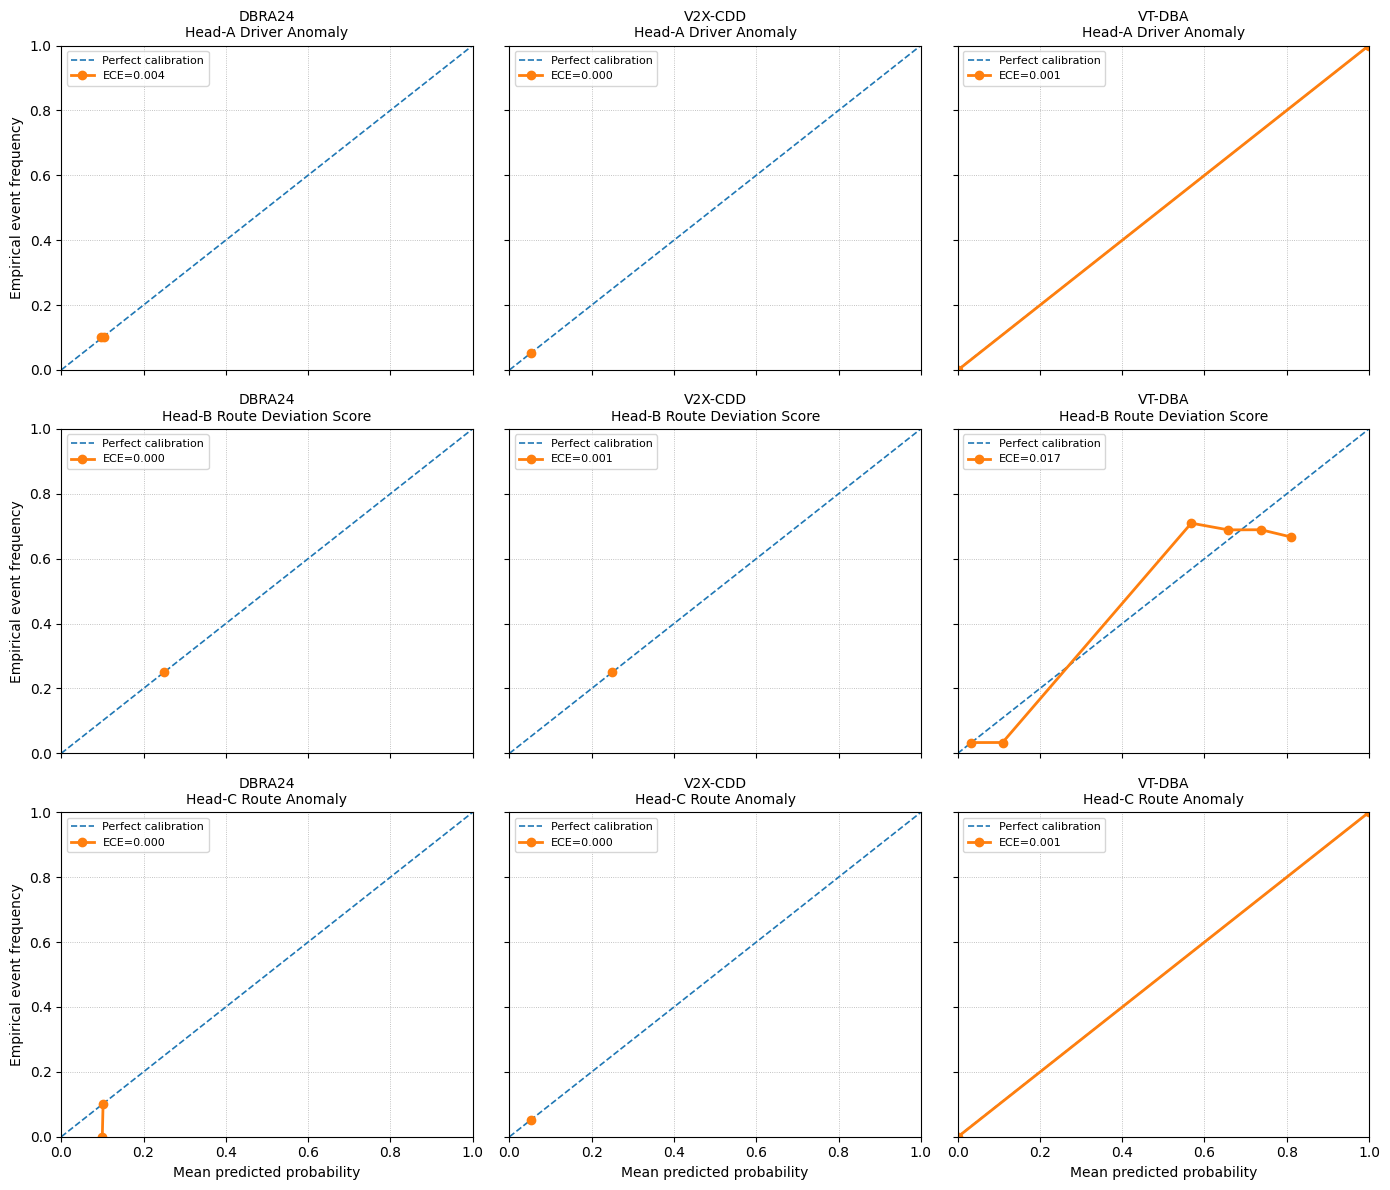


Saved files:
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Heads.png
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Heads.pdf
/kaggle/working/reliability_diagrams/reliability_summary.csv


,Dataset,Head,ECE,Brier,NLL,Samples
0,DBRA24,Head-A Driver Anomaly,0.004238,0.090754,0.327268,9000
1,V2X-CDD,Head-A Driver Anomaly,0.000348,0.049582,0.206115,690
2,VT-DBA,Head-A Driver Anomaly,0.000546,0.000006,0.000549,9000
3,DBRA24,Head-B Route Deviation Score,0.000084,0.187585,0.562561,9000
4,V2X-CDD,Head-B Route Deviation Score,0.000726,0.188203,0.564061,690
5,VT-DBA,Head-B Route Deviation Score,0.017133,0.092714,0.292363,9000
6,DBRA24,Head-C Route Anomaly,0.000097,0.091242,0.328487,9000
7,V2X-CDD,Head-C Route Anomaly,0.000348,0.049582,0.206115,690
8,VT-DBA,Head-C Route Anomaly,0.000546,0.000006,0.000549,9000


In [1]:
# ============================================================
# Standalone Reliability Diagrams for 3 Datasets
# Fast, independent, Kaggle-ready
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss, mean_squared_error

# -----------------------------
# Paths
# -----------------------------
DATASETS = {
    "DBRA24": "/kaggle/input/datasets/mishauroojkhan/edge-aware-digital-twin-mutiple-datasets/DABRA24.csv",
    "V2X-CDD": "/kaggle/input/datasets/mishauroojkhan/edge-aware-digital-twin-mutiple-datasets/V2X-VANET Cooperative Driving Dataset.csv",
    "VT-DBA": "/kaggle/input/datasets/mishauroojkhan/edge-aware-digital-twin-mutiple-datasets/Vehicle Telemetry for Driver Behavior Analysis.csv"
}

OUT_DIR = "/kaggle/working/reliability_diagrams"
os.makedirs(OUT_DIR, exist_ok=True)

RANDOM_STATE = 42
MAX_ROWS = 30000
N_BINS = 10

# -----------------------------
# Helper functions
# -----------------------------
def find_first_existing(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def make_binary_label(series):
    if series.dtype == "object":
        s = series.astype(str).str.lower()
        risky_words = ["anomaly", "abnormal", "aggressive", "distracted", "risky", "unsafe", "collision", "1", "true", "yes"]
        return s.apply(lambda x: int(any(w in x for w in risky_words))).astype(int)
    return (pd.to_numeric(series, errors="coerce").fillna(0) > 0).astype(int)

def make_quantile_binary(series, q=0.75):
    x = pd.to_numeric(series, errors="coerce")
    threshold = x.quantile(q)
    return (x >= threshold).astype(int)

def expected_calibration_error(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), 1e-7, 1 - 1e-7)

    edges = np.linspace(0, 1, n_bins + 1)
    ece = 0.0

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() == 0:
            continue

        acc = y_true[mask].mean()
        conf = y_prob[mask].mean()
        ece += (mask.sum() / len(y_true)) * abs(acc - conf)

    return float(ece)

def reliability_points(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), 1e-7, 1 - 1e-7)

    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys, counts = [], [], []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() > 0:
            xs.append(y_prob[mask].mean())
            ys.append(y_true[mask].mean())
            counts.append(mask.sum())

    return np.array(xs), np.array(ys), np.array(counts)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
    categorical_cols = [c for c in X.columns if c not in numeric_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    return ColumnTransformer([
        ("num", numeric_pipe, numeric_cols),
        ("cat", categorical_pipe, categorical_cols)
    ])

def train_calibrated_head(df, target, drop_cols):
    y = make_binary_label(df[target])

    X = df.drop(columns=list(set(drop_cols + [target])), errors="ignore")
    X = X.drop(columns=[c for c in X.columns if "timestamp" in c.lower()], errors="ignore")

    valid = y.notna()
    X = X.loc[valid].copy()
    y = y.loc[valid].astype(int).copy()

    if y.nunique() < 2:
        print(f"Skipping {target}: only one class found.")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y
    )

    pre = build_preprocessor(X_train)

    base = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=300, solver="liblinear", class_weight="balanced"))
    ])

    model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]

    return {
        "y_true": y_test.values,
        "y_prob": prob,
        "ece": expected_calibration_error(y_test.values, prob, N_BINS),
        "brier": brier_score_loss(y_test.values, prob),
        "nll": log_loss(y_test.values, np.clip(prob, 1e-7, 1 - 1e-7))
    }

def train_regression_as_reliability_head(df, target, drop_cols):
    # Converts continuous route deviation score into high-risk probability using quantile label.
    y_binary = make_quantile_binary(df[target], q=0.75)

    X = df.drop(columns=list(set(drop_cols + [target])), errors="ignore")
    X = X.drop(columns=[c for c in X.columns if "timestamp" in c.lower()], errors="ignore")

    if y_binary.nunique() < 2:
        print(f"Skipping {target}: only one class found after quantile split.")
        return None

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_binary,
        test_size=0.30,
        random_state=RANDOM_STATE,
        stratify=y_binary
    )

    pre = build_preprocessor(X_train)

    base = Pipeline([
        ("pre", pre),
        ("clf", LogisticRegression(max_iter=300, solver="liblinear", class_weight="balanced"))
    ])

    model = CalibratedClassifierCV(base, method="sigmoid", cv=3)
    model.fit(X_train, y_train)

    prob = model.predict_proba(X_test)[:, 1]

    return {
        "y_true": y_test.values,
        "y_prob": prob,
        "ece": expected_calibration_error(y_test.values, prob, N_BINS),
        "brier": brier_score_loss(y_test.values, prob),
        "nll": log_loss(y_test.values, np.clip(prob, 1e-7, 1 - 1e-7))
    }

# -----------------------------
# Dataset-specific target mapping
# -----------------------------
def get_heads(df, dataset_name):
    if dataset_name == "DBRA24":
        return {
            "Head-A Driver Anomaly": find_first_existing(df, ["anomalous_event", "driver_anomaly", "behavior_label"]),
            "Head-B Route Deviation Score": find_first_existing(df, ["route_deviation_score"]),
            "Head-C Route Anomaly": find_first_existing(df, ["route_anomaly", "geofencing_violation"])
        }

    if dataset_name == "V2X-CDD":
        return {
            "Head-A Driver Anomaly": find_first_existing(df, ["collision_detected"]),
            "Head-B Route Deviation Score": find_first_existing(df, ["latency_ms", "packet_drop_rate"]),
            "Head-C Route Anomaly": find_first_existing(df, ["collision_detected"])
        }

    if dataset_name == "VT-DBA":
        return {
            "Head-A Driver Anomaly": find_first_existing(df, ["behavior_label"]),
            "Head-B Route Deviation Score": find_first_existing(df, ["lane_deviation", "reaction_time"]),
            "Head-C Route Anomaly": find_first_existing(df, ["behavior_label"])
        }

    return {}

# -----------------------------
# Run all datasets
# -----------------------------
results = {}

for dataset_name, path in DATASETS.items():
    print(f"\nProcessing: {dataset_name}")
    df = pd.read_csv(path)

    if len(df) > MAX_ROWS:
        df = df.sample(MAX_ROWS, random_state=RANDOM_STATE).reset_index(drop=True)

    heads = get_heads(df, dataset_name)
    results[dataset_name] = {}

    drop_cols = [
        "trip_id", "driver_id", "vehicle_id",
        "anomalous_event", "route_anomaly", "route_deviation_score",
        "collision_detected", "behavior_label"
    ]

    for head_name, target in heads.items():
        if target is None:
            print(f"  Missing target for {head_name}")
            continue

        print(f"  {head_name} -> target: {target}")

        if "Deviation Score" in head_name:
            out = train_regression_as_reliability_head(df, target, drop_cols)
        else:
            out = train_calibrated_head(df, target, drop_cols)

        if out is not None:
            results[dataset_name][head_name] = out
            print(f"    ECE={out['ece']:.4f}, Brier={out['brier']:.4f}, NLL={out['nll']:.4f}")

# -----------------------------
# Plot reliability diagrams
# -----------------------------
dataset_order = ["DBRA24", "V2X-CDD", "VT-DBA"]
head_order = [
    "Head-A Driver Anomaly",
    "Head-B Route Deviation Score",
    "Head-C Route Anomaly"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(14, 12),
    sharex=True,
    sharey=True
)

summary_rows = []

for r, head_name in enumerate(head_order):
    for c, dataset_name in enumerate(dataset_order):
        ax = axes[r, c]
        ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, label="Perfect calibration")

        if dataset_name in results and head_name in results[dataset_name]:
            out = results[dataset_name][head_name]
            xs, ys, counts = reliability_points(out["y_true"], out["y_prob"], N_BINS)

            ax.plot(xs, ys, marker="o", linewidth=2, label=f"ECE={out['ece']:.3f}")

            summary_rows.append({
                "Dataset": dataset_name,
                "Head": head_name,
                "ECE": out["ece"],
                "Brier": out["brier"],
                "NLL": out["nll"],
                "Samples": len(out["y_true"])
            })

        ax.set_title(f"{dataset_name}\n{head_name}", fontsize=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, linestyle=":", linewidth=0.6)
        ax.legend(fontsize=8, loc="best")

        if r == 2:
            ax.set_xlabel("Mean predicted probability")
        if c == 0:
            ax.set_ylabel("Empirical event frequency")

plt.tight_layout()

png_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Heads.png")
pdf_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Heads.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, "reliability_summary.csv")
summary.to_csv(summary_path, index=False)

print("\nSaved files:")
print(png_path)
print(pdf_path)
print(summary_path)

display(summary)

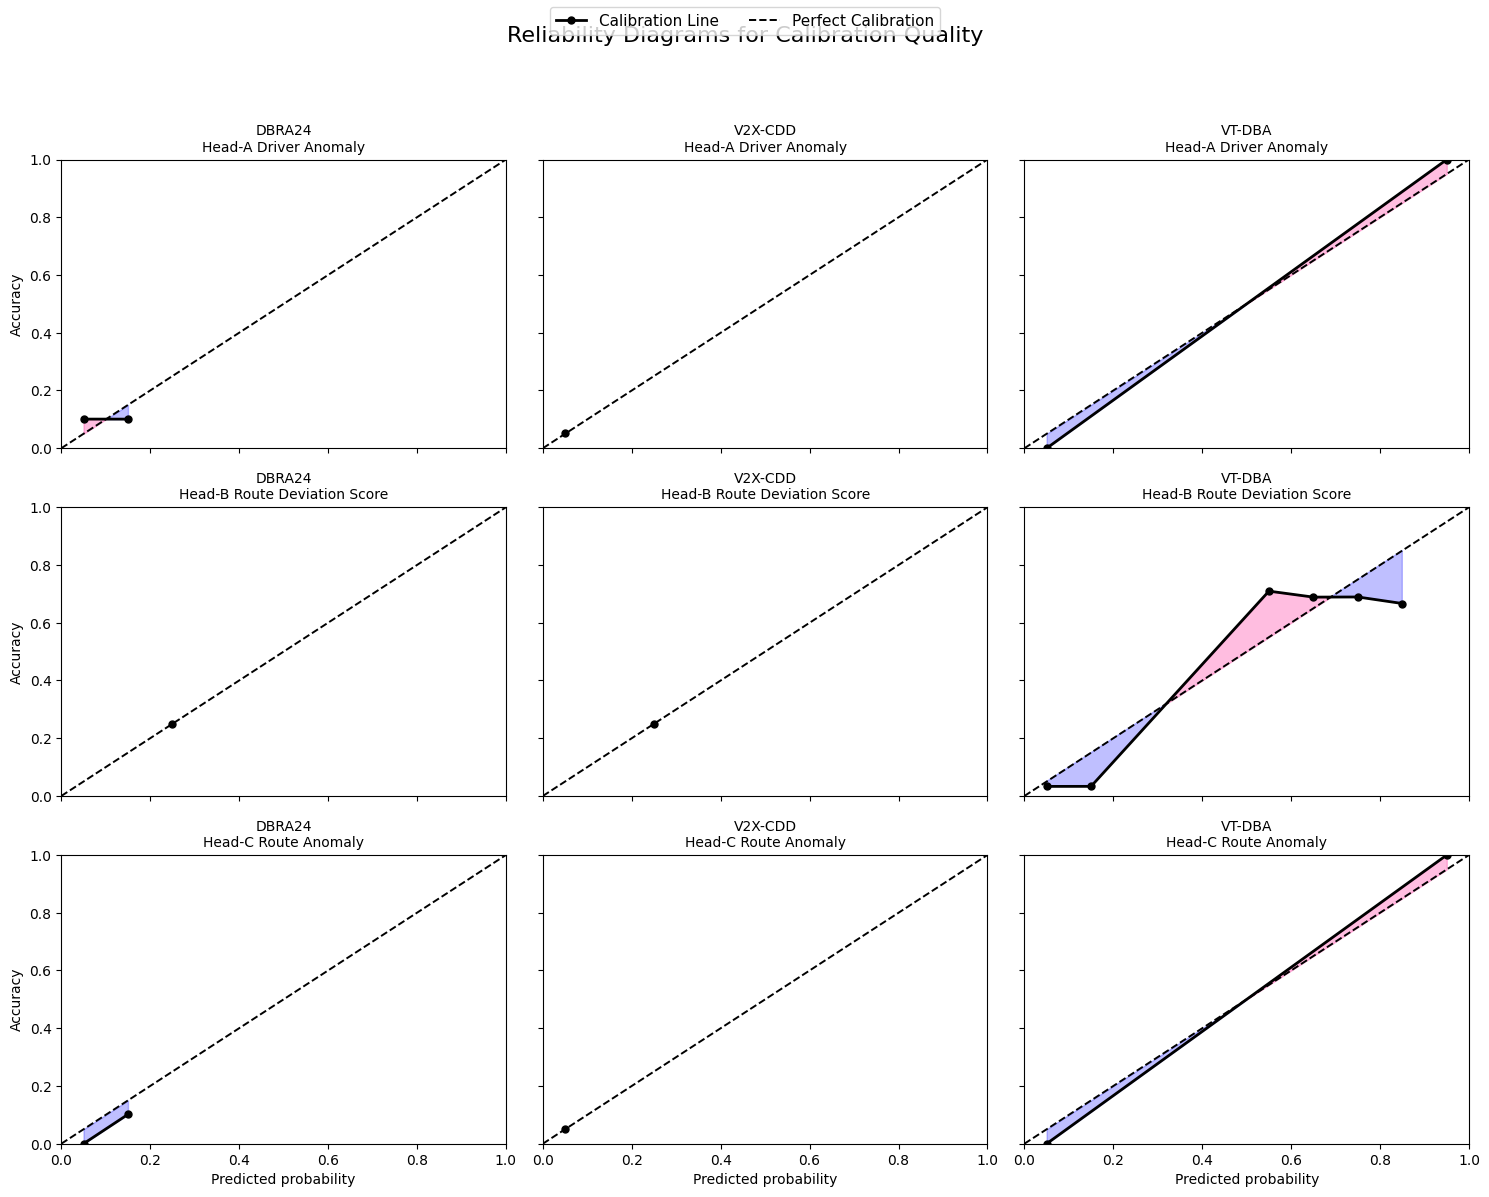

Saved:
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_ExampleStyle_3Datasets_3Heads.png
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_ExampleStyle_3Datasets_3Heads.pdf


In [2]:
# ============================================================
# Reliability diagrams like reviewer example: 3 datasets x 3 heads
# Run after the previous code has created `results`
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "/kaggle/working/reliability_diagrams"
os.makedirs(OUT_DIR, exist_ok=True)

def reliability_points_fixed_bins(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), 1e-7, 1 - 1e-7)

    edges = np.linspace(0, 1, n_bins + 1)
    centers, accs = [], []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (y_prob >= lo) & (y_prob < hi) if i < n_bins - 1 else (y_prob >= lo) & (y_prob <= hi)

        if mask.sum() > 0:
            centers.append(0.5 * (lo + hi))
            accs.append(y_true[mask].mean())

    return np.array(centers), np.array(accs)

def plot_reliability_like_example(ax, y_true, y_prob, title, n_bins=10):
    x, y = reliability_points_fixed_bins(y_true, y_prob, n_bins=n_bins)

    ax.plot(x, y, "-o", color="black", linewidth=2, markersize=5, label="Calibration Line")
    ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1.4, label="Perfect Calibration")

    if len(x) > 1:
        under = y > x
        over = y < x

        ax.fill_between(
            x, x, y,
            where=under,
            interpolate=True,
            alpha=0.28,
            color="deeppink"
        )

        ax.fill_between(
            x, x, y,
            where=over,
            interpolate=True,
            alpha=0.25,
            color="blue"
        )

    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(False)

    return x, y

dataset_order = ["DBRA24", "V2X-CDD", "VT-DBA"]

head_order = [
    "Head-A Driver Anomaly",
    "Head-B Route Deviation Score",
    "Head-C Route Anomaly"
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12), sharex=True, sharey=True)

for r, head_name in enumerate(head_order):
    for c, dataset_name in enumerate(dataset_order):
        ax = axes[r, c]

        if dataset_name in results and head_name in results[dataset_name]:
            out = results[dataset_name][head_name]
            plot_reliability_like_example(
                ax,
                out["y_true"],
                out["y_prob"],
                f"{dataset_name}\n{head_name}",
                n_bins=10
            )
        else:
            ax.plot([0, 1], [0, 1], "--", color="black", linewidth=1.4)
            ax.set_title(f"{dataset_name}\n{head_name}\nMissing target", fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)

        if r == 2:
            ax.set_xlabel("Predicted probability", fontsize=10)
        if c == 0:
            ax.set_ylabel("Accuracy", fontsize=10)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, fontsize=11)

fig.suptitle("Reliability Diagrams for Calibration Quality", fontsize=16, y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.94])

png_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_ExampleStyle_3Datasets_3Heads.png")
pdf_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_ExampleStyle_3Datasets_3Heads.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print("Saved:")
print(png_path)
print(pdf_path)

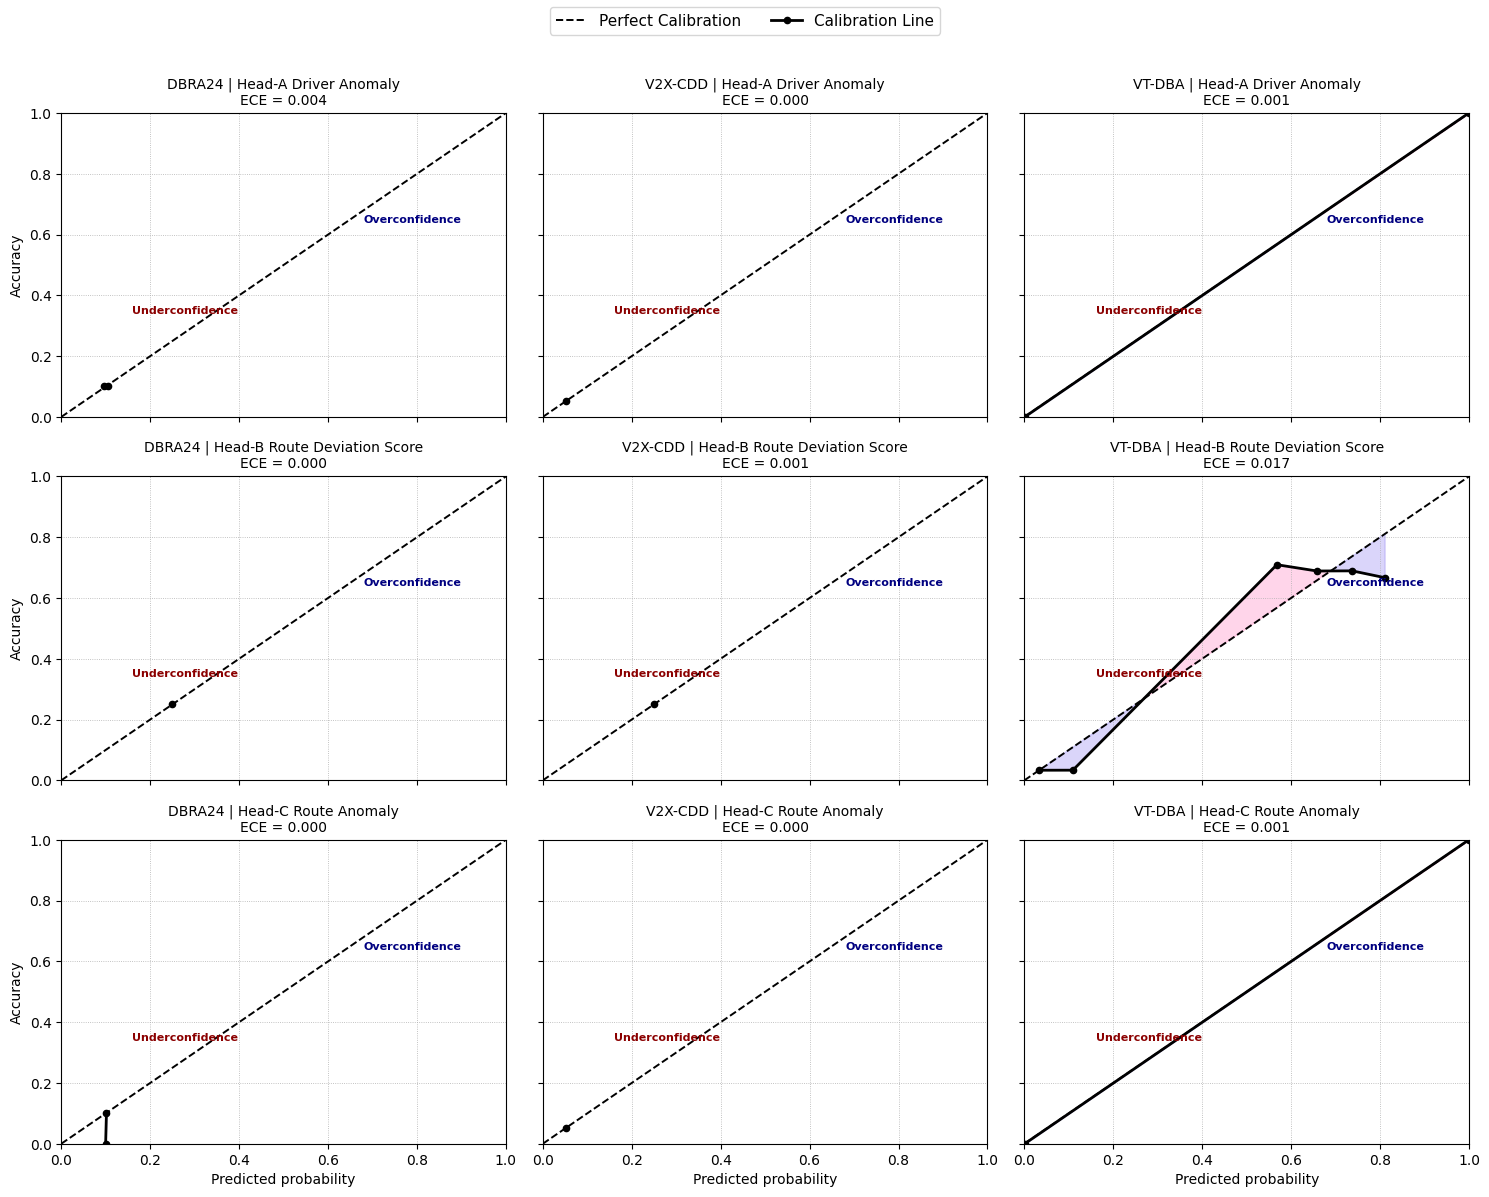

Saved:
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Datasets_3Heads_Shaded.png
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Datasets_3Heads_Shaded.pdf
/kaggle/working/reliability_diagrams/reliability_summary_shaded.csv


,Dataset,Head,ECE,Brier,NLL,Samples
0,DBRA24,Head-A Driver Anomaly,0.004238,0.090754,0.327268,9000
1,V2X-CDD,Head-A Driver Anomaly,0.000348,0.049582,0.206115,690
2,VT-DBA,Head-A Driver Anomaly,0.000546,0.000006,0.000549,9000
3,DBRA24,Head-B Route Deviation Score,0.000084,0.187585,0.562561,9000
4,V2X-CDD,Head-B Route Deviation Score,0.000726,0.188203,0.564061,690
5,VT-DBA,Head-B Route Deviation Score,0.017133,0.092714,0.292363,9000
6,DBRA24,Head-C Route Anomaly,0.000097,0.091242,0.328487,9000
7,V2X-CDD,Head-C Route Anomaly,0.000348,0.049582,0.206115,690
8,VT-DBA,Head-C Route Anomaly,0.000546,0.000006,0.000549,9000


In [3]:
# ============================================================
# Reliability diagrams with Underconfidence / Overconfidence
# 3 datasets × 3 heads
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/kaggle/working/reliability_diagrams"
os.makedirs(OUT_DIR, exist_ok=True)

def reliability_points(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), 1e-7, 1 - 1e-7)

    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]

        if i == n_bins - 1:
            mask = (y_prob >= lo) & (y_prob <= hi)
        else:
            mask = (y_prob >= lo) & (y_prob < hi)

        if mask.sum() > 0:
            xs.append(y_prob[mask].mean())
            ys.append(y_true[mask].mean())

    return np.array(xs), np.array(ys)

def plot_one_reliability(ax, y_true, y_prob, title, ece_value=None, n_bins=10):
    x, y = reliability_points(y_true, y_prob, n_bins=n_bins)

    # Perfect calibration diagonal
    ax.plot([0, 1], [0, 1], "k--", linewidth=1.4, label="Perfect Calibration")

    # Calibration curve
    ax.plot(
        x, y,
        color="black",
        marker="o",
        linewidth=2,
        markersize=4.5,
        label="Calibration Line"
    )

    # Shaded confidence regions
    if len(x) > 1:
        diagonal_y = x

        # Underconfidence: empirical accuracy > predicted probability
        ax.fill_between(
            x,
            diagonal_y,
            y,
            where=(y > diagonal_y),
            interpolate=True,
            alpha=0.28,
            color="hotpink"
        )

        # Overconfidence: empirical accuracy < predicted probability
        ax.fill_between(
            x,
            y,
            diagonal_y,
            where=(y < diagonal_y),
            interpolate=True,
            alpha=0.28,
            color="mediumslateblue"
        )

    # Text labels
    ax.text(
        0.16, 0.34,
        "Underconfidence",
        fontsize=8,
        color="darkred",
        fontweight="bold"
    )

    ax.text(
        0.68, 0.64,
        "Overconfidence",
        fontsize=8,
        color="navy",
        fontweight="bold"
    )

    if ece_value is not None:
        title = f"{title}\nECE = {ece_value:.3f}"

    ax.set_title(title, fontsize=10)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", linewidth=0.6)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Accuracy")

# -----------------------------
# Plot grid
# -----------------------------
dataset_order = ["DBRA24", "V2X-CDD", "VT-DBA"]

head_order = [
    "Head-A Driver Anomaly",
    "Head-B Route Deviation Score",
    "Head-C Route Anomaly"
]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(15, 12),
    sharex=True,
    sharey=True
)

summary_rows = []

for r, head_name in enumerate(head_order):
    for c, dataset_name in enumerate(dataset_order):
        ax = axes[r, c]

        if dataset_name in results and head_name in results[dataset_name]:
            out = results[dataset_name][head_name]

            plot_one_reliability(
                ax=ax,
                y_true=out["y_true"],
                y_prob=out["y_prob"],
                title=f"{dataset_name} | {head_name}",
                ece_value=out["ece"],
                n_bins=10
            )

            summary_rows.append({
                "Dataset": dataset_name,
                "Head": head_name,
                "ECE": out["ece"],
                "Brier": out["brier"],
                "NLL": out["nll"],
                "Samples": len(out["y_true"])
            })

        else:
            ax.plot([0, 1], [0, 1], "k--", linewidth=1.4)
            ax.set_title(f"{dataset_name} | {head_name}\nMissing target", fontsize=10)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle=":", linewidth=0.6)

        if r != 2:
            ax.set_xlabel("")
        if c != 0:
            ax.set_ylabel("")

# One clean legend
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

png_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Datasets_3Heads_Shaded.png")
pdf_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Datasets_3Heads_Shaded.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, "reliability_summary_shaded.csv")
summary.to_csv(summary_path, index=False)

print("Saved:")
print(png_path)
print(pdf_path)
print(summary_path)

display(summary)

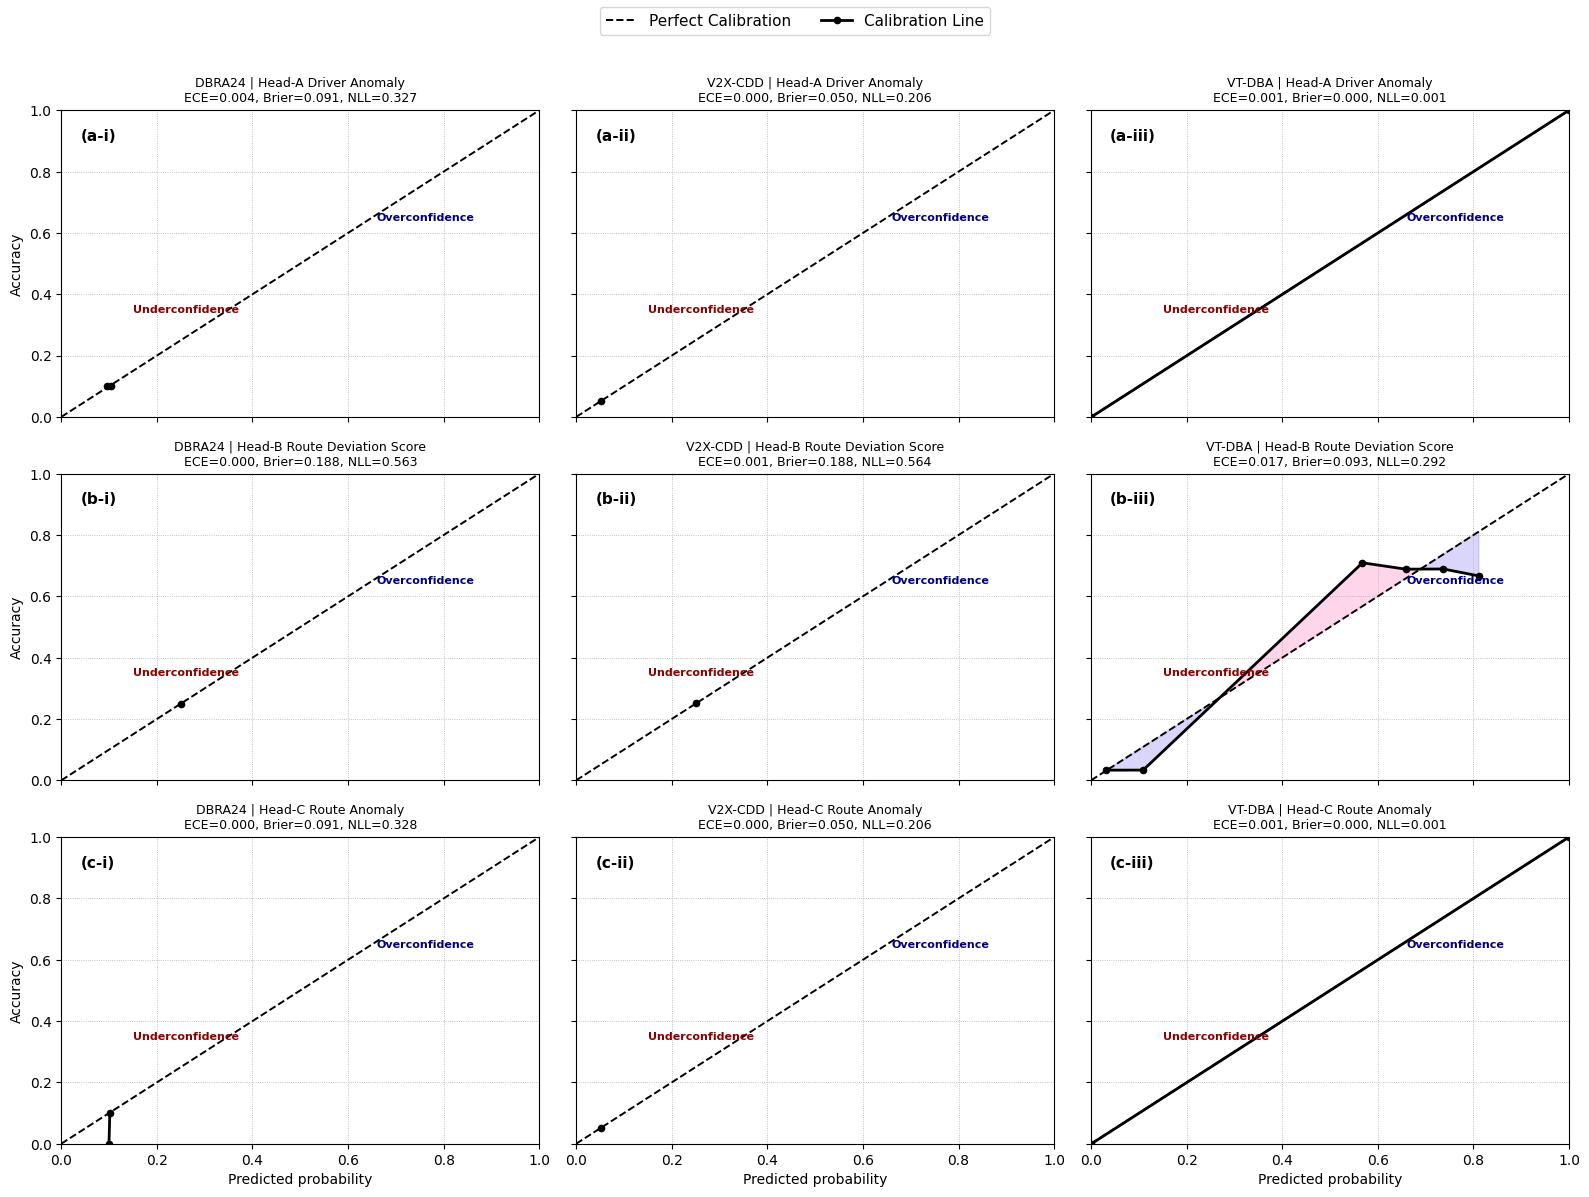

Saved:
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Datasets_3Heads_Metrics_Panels.png
/kaggle/working/reliability_diagrams/Fig_Reliability_Diagrams_3Datasets_3Heads_Metrics_Panels.pdf
/kaggle/working/reliability_diagrams/reliability_summary_metrics_panels.csv


,Panel,Dataset,Head,ECE,Brier,NLL,Samples
0,(a-i),DBRA24,Head-A Driver Anomaly,0.004238,0.090754,0.327268,9000
1,(a-ii),V2X-CDD,Head-A Driver Anomaly,0.000348,0.049582,0.206115,690
2,(a-iii),VT-DBA,Head-A Driver Anomaly,0.000546,0.000006,0.000549,9000
3,(b-i),DBRA24,Head-B Route Deviation Score,0.000084,0.187585,0.562561,9000
4,(b-ii),V2X-CDD,Head-B Route Deviation Score,0.000726,0.188203,0.564061,690
5,(b-iii),VT-DBA,Head-B Route Deviation Score,0.017133,0.092714,0.292363,9000
6,(c-i),DBRA24,Head-C Route Anomaly,0.000097,0.091242,0.328487,9000
7,(c-ii),V2X-CDD,Head-C Route Anomaly,0.000348,0.049582,0.206115,690
8,(c-iii),VT-DBA,Head-C Route Anomaly,0.000546,0.000006,0.000549,9000


In [4]:
# ============================================================
# Reliability diagrams with panel labels and all metrics in title
# 3 datasets × 3 heads
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUT_DIR = "/kaggle/working/reliability_diagrams"
os.makedirs(OUT_DIR, exist_ok=True)

def reliability_points(y_true, y_prob, n_bins=10):
    y_true = np.asarray(y_true).astype(int)
    y_prob = np.clip(np.asarray(y_prob).astype(float), 1e-7, 1 - 1e-7)

    edges = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []

    for i in range(n_bins):
        lo, hi = edges[i], edges[i + 1]
        mask = (y_prob >= lo) & (y_prob <= hi) if i == n_bins - 1 else (y_prob >= lo) & (y_prob < hi)

        if mask.sum() > 0:
            xs.append(y_prob[mask].mean())
            ys.append(y_true[mask].mean())

    return np.array(xs), np.array(ys)

def plot_one_reliability(ax, y_true, y_prob, title, ece_value, brier_value, nll_value, panel_label, n_bins=10):
    x, y = reliability_points(y_true, y_prob, n_bins=n_bins)

    ax.plot([0, 1], [0, 1], "k--", linewidth=1.4, label="Perfect Calibration")

    ax.plot(
        x, y,
        color="black",
        marker="o",
        linewidth=2,
        markersize=4.5,
        label="Calibration Line"
    )

    if len(x) > 1:
        diagonal_y = x

        ax.fill_between(
            x, diagonal_y, y,
            where=(y > diagonal_y),
            interpolate=True,
            alpha=0.28,
            color="hotpink"
        )

        ax.fill_between(
            x, y, diagonal_y,
            where=(y < diagonal_y),
            interpolate=True,
            alpha=0.28,
            color="mediumslateblue"
        )

    ax.text(
        0.04, 0.94,
        panel_label,
        transform=ax.transAxes,
        fontsize=11,
        fontweight="bold",
        va="top",
        ha="left"
    )

    ax.text(
        0.15, 0.34,
        "Underconfidence",
        fontsize=8,
        color="darkred",
        fontweight="bold"
    )

    ax.text(
        0.66, 0.64,
        "Overconfidence",
        fontsize=8,
        color="navy",
        fontweight="bold"
    )

    ax.set_title(
        f"{title}\nECE={ece_value:.3f}, Brier={brier_value:.3f}, NLL={nll_value:.3f}",
        fontsize=9
    )

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, linestyle=":", linewidth=0.6)
    ax.set_xlabel("Predicted probability")
    ax.set_ylabel("Accuracy")

dataset_order = ["DBRA24", "V2X-CDD", "VT-DBA"]

head_order = [
    "Head-A Driver Anomaly",
    "Head-B Route Deviation Score",
    "Head-C Route Anomaly"
]

row_letters = ["a", "b", "c"]
col_roman = ["i", "ii", "iii"]

fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(16, 12),
    sharex=True,
    sharey=True
)

summary_rows = []

for r, head_name in enumerate(head_order):
    for c, dataset_name in enumerate(dataset_order):
        ax = axes[r, c]
        panel_label = f"({row_letters[r]}-{col_roman[c]})"

        if dataset_name in results and head_name in results[dataset_name]:
            out = results[dataset_name][head_name]

            plot_one_reliability(
                ax=ax,
                y_true=out["y_true"],
                y_prob=out["y_prob"],
                title=f"{dataset_name} | {head_name}",
                ece_value=out["ece"],
                brier_value=out["brier"],
                nll_value=out["nll"],
                panel_label=panel_label,
                n_bins=10
            )

            summary_rows.append({
                "Panel": panel_label,
                "Dataset": dataset_name,
                "Head": head_name,
                "ECE": out["ece"],
                "Brier": out["brier"],
                "NLL": out["nll"],
                "Samples": len(out["y_true"])
            })

        else:
            ax.plot([0, 1], [0, 1], "k--", linewidth=1.4)
            ax.text(
                0.04, 0.94,
                panel_label,
                transform=ax.transAxes,
                fontsize=11,
                fontweight="bold",
                va="top",
                ha="left"
            )
            ax.set_title(f"{dataset_name} | {head_name}\nMissing target", fontsize=9)
            ax.set_xlim(0, 1)
            ax.set_ylim(0, 1)
            ax.grid(True, linestyle=":", linewidth=0.6)

        if r != 2:
            ax.set_xlabel("")
        if c != 0:
            ax.set_ylabel("")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11,
    frameon=True
)

plt.tight_layout(rect=[0, 0, 1, 0.95])

png_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Datasets_3Heads_Metrics_Panels.png")
pdf_path = os.path.join(OUT_DIR, "Fig_Reliability_Diagrams_3Datasets_3Heads_Metrics_Panels.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

summary = pd.DataFrame(summary_rows)
summary_path = os.path.join(OUT_DIR, "reliability_summary_metrics_panels.csv")
summary.to_csv(summary_path, index=False)

print("Saved:")
print(png_path)
print(pdf_path)
print(summary_path)

display(summary)